# 00. Environment Validation

Use this notebook before starting the Section 1 exercises. It verifies that this project was installed from `requirements.txt`, checks the main Python libraries, and runs a small Qiskit simulator test.

## Install the dependencies

From the project root, install the pinned environment with:

```bash
pip install -r requirements.txt
```

If the notebook kernel is different from the terminal environment, install with the same Python executable used by this notebook:

```python
import sys
!{sys.executable} -m pip install -r ../requirements.txt
```

In [ ]:
from __future__ import annotations

import importlib
import platform
import sys
from importlib import metadata
from pathlib import Path

from packaging.requirements import Requirement
from packaging.version import Version

project_root = Path.cwd().resolve().parent if Path.cwd().name == "section_1_perform_quantum_operations" else Path.cwd().resolve()
requirements_file = project_root / "requirements.txt"

print("Python environment")
print(f"Executable : {sys.executable}")
print(f"Version    : {sys.version.split()[0]}")
print(f"Platform   : {platform.platform()}")
print(f"Project    : {project_root}")
print(f"Requirements file exists: {requirements_file.exists()}")

In [ ]:
core_imports = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "qiskit": "qiskit",
    "qiskit-aer": "qiskit_aer",
    "qiskit-algorithms": "qiskit_algorithms",
    "qiskit-ibm-runtime": "qiskit_ibm_runtime",
    "qiskit-machine-learning": "qiskit_machine_learning",
    "qiskit-optimization": "qiskit_optimization",
}

for package_name, import_name in core_imports.items():
    try:
        module = importlib.import_module(import_name)
        version = getattr(module, "__version__", metadata.version(package_name))
        print(f"[OK]   {package_name:<24} import={import_name:<24} version={version}")
    except Exception as exc:
        print(f"[FAIL] {package_name:<24} import={import_name:<24} error={exc}")

In [3]:
def read_requirements(path: Path) -> list[Requirement]:
    requirements = []
    for line in path.read_text(encoding="utf-8").splitlines():
        cleaned = line.strip()
        if cleaned and not cleaned.startswith("#"):
            requirements.append(Requirement(cleaned))
    return requirements


def installed_version(package_name: str) -> str | None:
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return None


missing = []
mismatched = []

for requirement in read_requirements(requirements_file):
    installed = installed_version(requirement.name)
    expected = str(requirement.specifier) or "any"
    if installed is None:
        missing.append(requirement.name)
        print(f"[FAIL]  {requirement.name:<32} expected={expected:<12} installed=missing")
    elif requirement.specifier and Version(installed) not in requirement.specifier:
        mismatched.append((requirement.name, expected, installed))
        print(f"[CHECK] {requirement.name:<32} expected={expected:<12} installed={installed}")
    else:
        print(f"[OK]    {requirement.name:<32} expected={expected:<12} installed={installed}")

print()
print(f"Missing packages: {len(missing)}")
print(f"Version mismatches: {len(mismatched)}")

[OK]    annotated-types                  expected===0.7.0      installed=0.7.0
[OK]    anyio                            expected===4.13.0     installed=4.13.0
[OK]    argon2-cffi                      expected===25.1.0     installed=25.1.0
[OK]    argon2-cffi-bindings             expected===25.1.0     installed=25.1.0
[OK]    arrow                            expected===1.4.0      installed=1.4.0
[OK]    asttokens                        expected===3.0.1      installed=3.0.1
[OK]    async-lru                        expected===2.3.0      installed=2.3.0
[OK]    attrs                            expected===26.1.0     installed=26.1.0
[OK]    babel                            expected===2.18.0     installed=2.18.0
[OK]    beautifulsoup4                   expected===4.14.3     installed=4.14.3
[OK]    bleach                           expected===6.3.0      installed=6.3.0
[OK]    certifi                          expected===2026.4.22  installed=2026.4.22
[OK]    cffi                             e

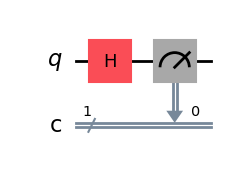

{'0': 64, '1': 64}
Qiskit Aer smoke test passed.


In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

circuit = QuantumCircuit(1, 1)
circuit.h(0)
circuit.measure(0, 0)

simulator = AerSimulator(seed_simulator=42)
result = simulator.run(circuit, shots=128).result()
counts = result.get_counts()

display(circuit.draw(output="mpl"))
print(counts)
assert sum(counts.values()) == 128
assert set(counts).issubset({"0", "1"})
print("Qiskit Aer smoke test passed.")